# Notebook 1: Dataset Selection, EDA & Preprocessing

**Capstone Project — IIoT Edge Computing Predictive Maintenance**

This notebook covers:
- **Task 1**: Dataset Selection & Justification
- **Task 2**: Data Understanding & Preprocessing

## Task 1: Dataset Selection & Justification

### Dataset
- **Name**: IIoT Edge Computing Dataset
- **Source**: [Kaggle — ziya07/iiot-edge-computing-dataset](https://www.kaggle.com/datasets/ziya07/iiot-edge-computing-dataset)
- **Records**: 1,000 sensor readings
- **Features**: 9 features (6 numerical + 3 categorical) + 1 binary target (`Predicted_Failure`)

### Domain Relevance
Industrial IoT (IIoT) edge computing systems are critical for real-time monitoring and predictive maintenance in manufacturing and industrial environments. This dataset captures sensor readings from industrial equipment including temperature, pressure, vibration, network latency, and edge processing metrics. Predicting equipment failures before they occur is essential for preventing costly downtime, reducing maintenance costs, and ensuring operational safety.

### Nature & Severity of Class Imbalance
The dataset exhibits moderate class imbalance with a 1.2:1 ratio between non-failure (546 samples, 54.6%) and failure cases (454 samples, 45.4%). While less severe than many real-world datasets, this imbalance still provides an opportunity to demonstrate resampling techniques (SMOTE, undersampling, hybrid methods) and their impact on model performance. In predictive maintenance, missing a failure (false negative) can be extremely costly, making recall optimization critical.

In [1]:
# Install required libraries
# !pip install kagglehub pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Download and load dataset


In [3]:
path = kagglehub.dataset_download("ziya07/iiot-edge-computing-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"Dataset Shape: {df.shape}")
print(f"Number of features: {df.shape[1] - 1}")
print(f"Number of records: {df.shape[0]:,}")
print(f"\nFeature columns: {df.columns.tolist()}")
df.head()

Dataset Shape: (1000, 10)
Number of features: 9
Number of records: 1,000

Feature columns: ['Timestamp', 'Sensor_ID', 'Temperature', 'Pressure', 'Vibration', 'Network_Latency', 'Edge_Processing_Time', 'Maintenance_Status', 'Fuzzy_PID_Output', 'Predicted_Failure']


,Timestamp,Sensor_ID,Temperature,Pressure,Vibration,Network_Latency,Edge_Processing_Time,Maintenance_Status,Fuzzy_PID_Output,Predicted_Failure
0,2024-04-03 00:00:00,S4,97.284731,111.489702,22.192447,31.291675,4.135729,Normal,0.98,0
1,2024-04-03 00:05:00,S5,82.605327,92.162530,38.670298,14.130600,12.181099,Failure,0.66,1
2,2024-04-03 00:10:00,S3,87.866033,92.137702,49.435335,16.900955,3.592472,Failure,0.55,1
3,2024-04-03 00:15:00,S5,96.899975,90.363254,25.703229,32.718972,10.253787,Normal,0.76,0
4,2024-04-03 00:20:00,S5,88.289545,118.695042,43.777853,21.854305,3.609998,Normal,0.53,1


In [4]:
# Data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             1000 non-null   object 
 1   Sensor_ID             1000 non-null   object 
 2   Temperature           1000 non-null   float64
 3   Pressure              1000 non-null   float64
 4   Vibration             1000 non-null   float64
 5   Network_Latency       1000 non-null   float64
 6   Edge_Processing_Time  1000 non-null   float64
 7   Maintenance_Status    1000 non-null   object 
 8   Fuzzy_PID_Output      1000 non-null   float64
 9   Predicted_Failure     1000 non-null   int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 78.3+ KB


In [5]:
# Descriptive statistics
df.describe()

,Temperature,Pressure,Vibration,Network_Latency,Edge_Processing_Time,Fuzzy_PID_Output,Predicted_Failure
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,80.009772,104.951817,34.950307,29.643237,8.475422,0.743890,0.454000
std,11.708741,8.663976,8.634938,11.437415,3.761469,0.142922,0.498129
min,60.185281,90.004041,20.000349,10.001229,2.012264,0.500000,0.000000
25%,69.427935,97.794425,27.425147,19.924765,5.239809,0.620000,0.000000
50%,80.174159,104.979852,35.062238,29.356462,8.310621,0.740000,0.000000
75%,89.801766,112.536819,42.450889,39.209143,11.721305,0.860000,1.000000
max,99.976549,119.950425,49.986731,49.909976,14.991554,1.000000,1.000000


In [7]:
# Class distribution
class_dist = df['Predicted_Failure'].value_counts()
print("Class Distribution:")
print(class_dist)
print(f"\nClass 0 (No Failure): {class_dist[0]} samples ({class_dist[0]/len(df)*100:.1f}%)")
print(f"Class 1 (Failure): {class_dist[1]} samples ({class_dist[1]/len(df)*100:.1f}%)")
print(f"\nImbalance ratio (majority/minority): {class_dist.max() / class_dist.min():.2f}")

Class Distribution:
Predicted_Failure
0    546
1    454
Name: count, dtype: int64

Class 0 (No Failure): 546 samples (54.6%)
Class 1 (Failure): 454 samples (45.4%)

Imbalance ratio (majority/minority): 1.20


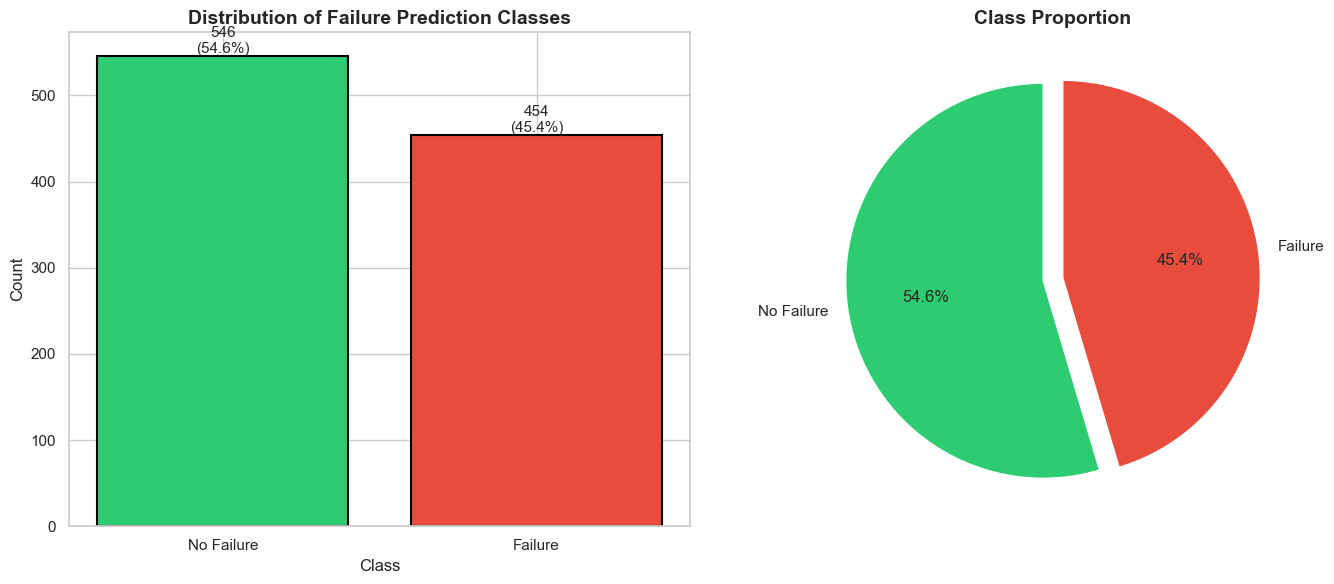

In [8]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
ax1 = axes[0]
class_labels = ['No Failure', 'Failure']
class_counts = [class_dist[0], class_dist[1]]
bars = ax1.bar(class_labels, class_counts, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax1.set_title('Distribution of Failure Prediction Classes', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_xlabel('Class')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

# Pie chart for proportions
ax2 = axes[1]
ax2.pie(class_counts, labels=class_labels, autopct='%1.1f%%', startangle=90,
        colors=['#2ecc71', '#e74c3c'], explode=(0.05, 0.05))
ax2.set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Target Variable Analysis — Class Imbalance

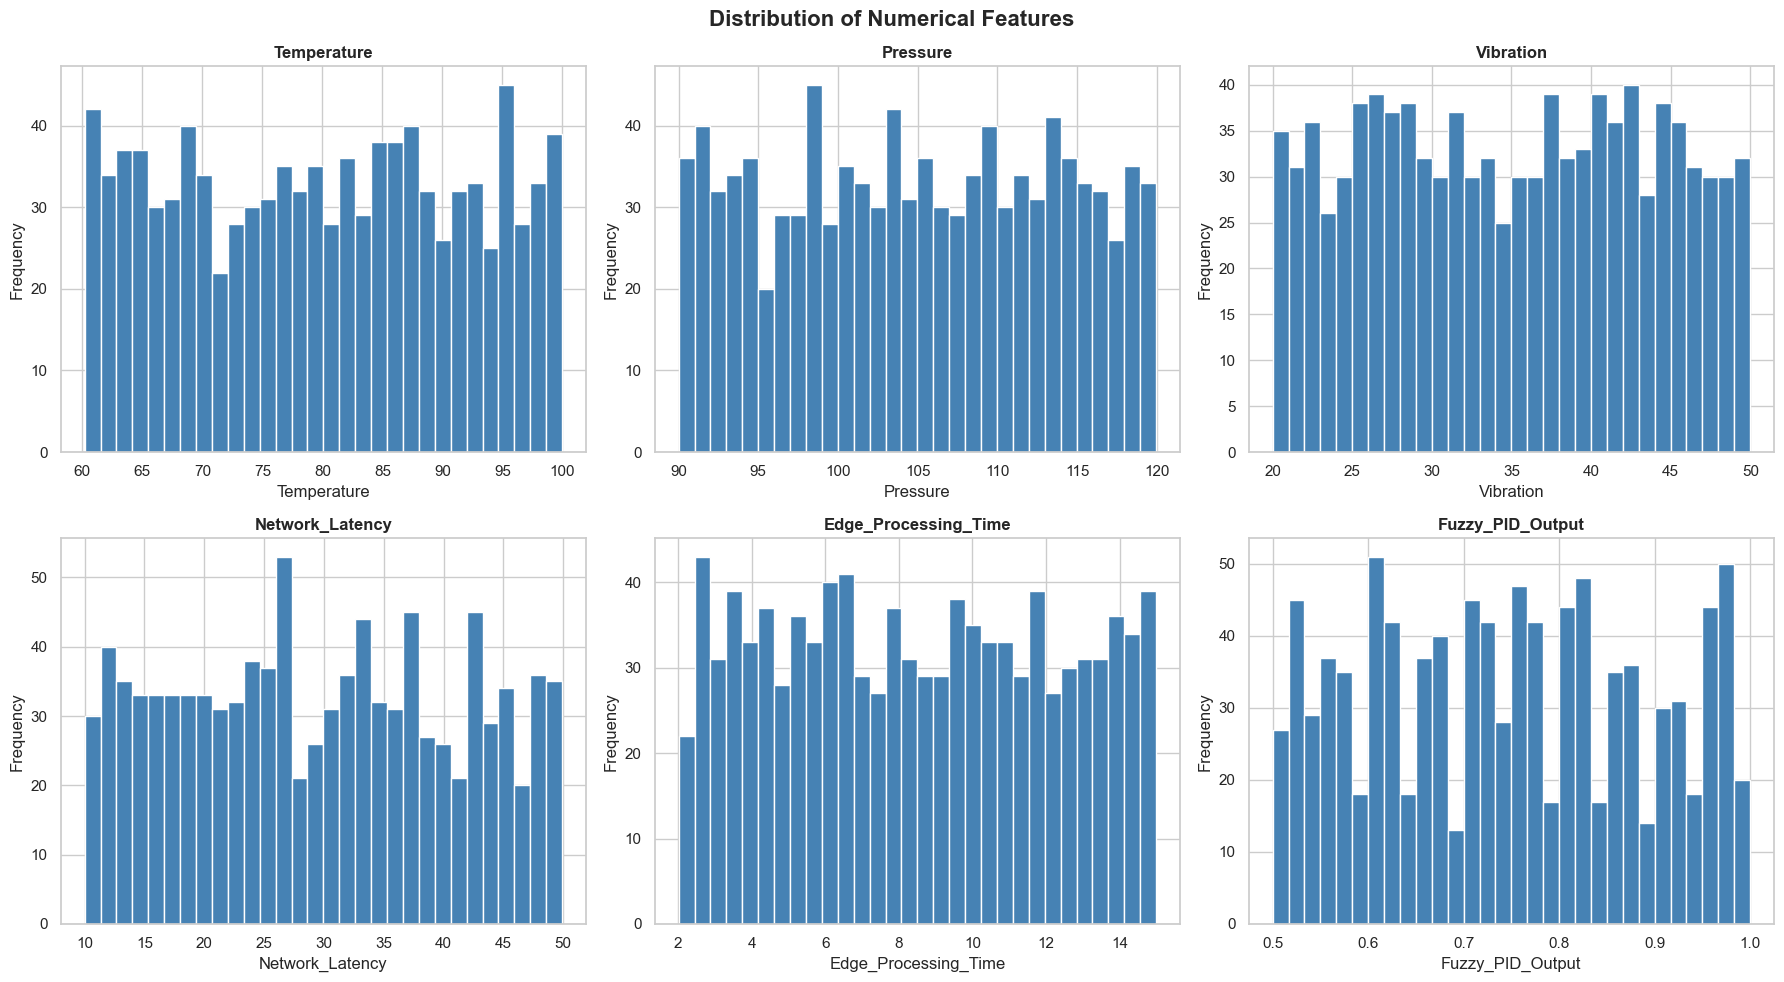

In [15]:
# Distribution of key continuous features
key_features = ['Temperature', 'Pressure', 'Vibration', 'Network_Latency', 'Edge_Processing_Time', 'Fuzzy_PID_Output']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    df[feat].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlabel(feat)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

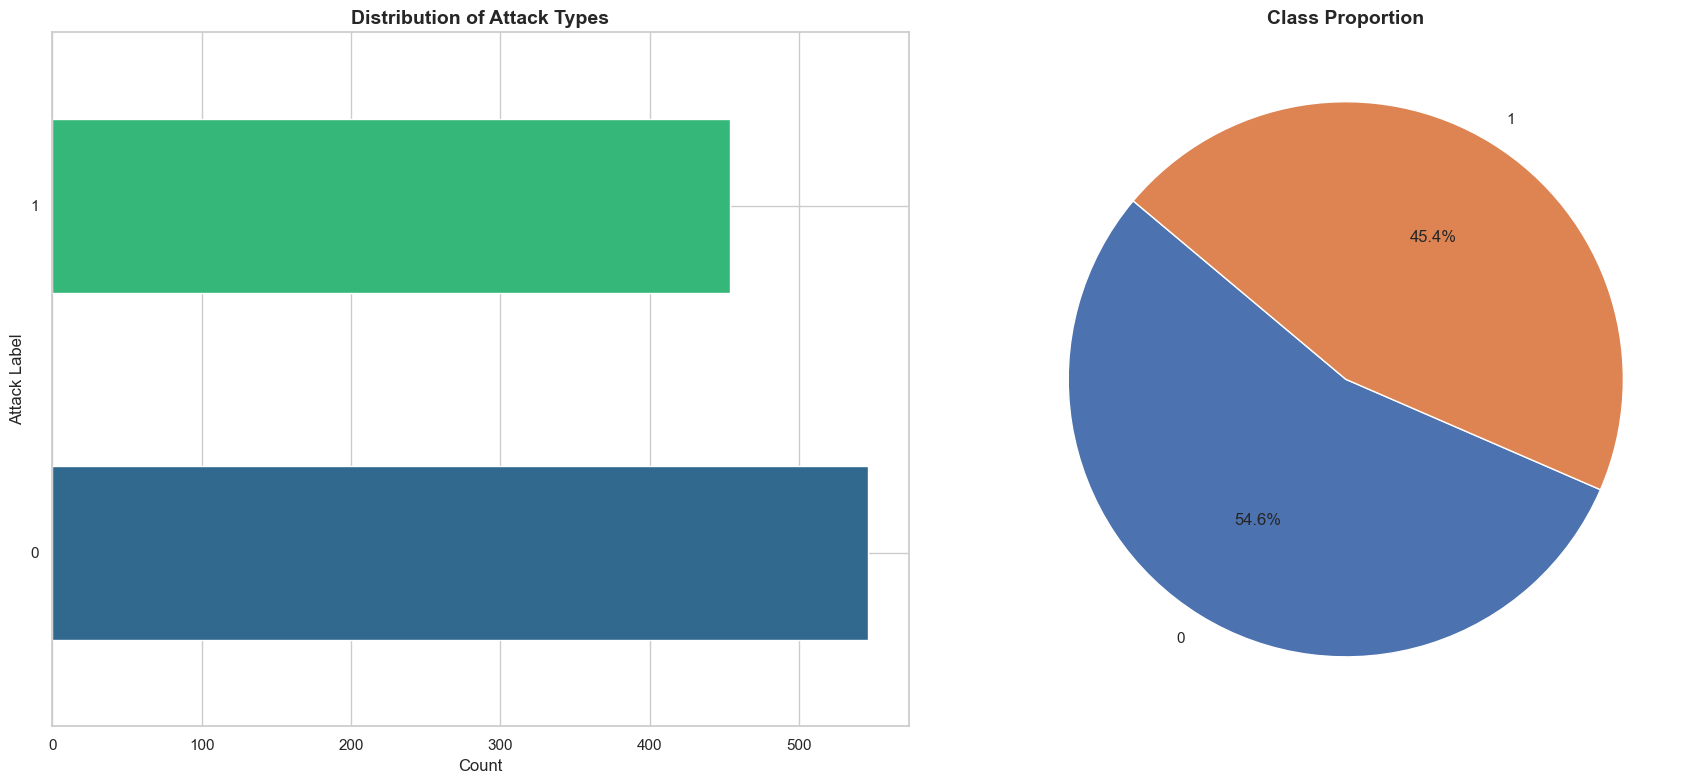

In [16]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart
ax1 = axes[0]
class_dist.plot(kind='barh', ax=ax1, color=sns.color_palette('viridis', len(class_dist)))
ax1.set_title('Distribution of Attack Types', fontsize=14, fontweight='bold')
ax1.set_xlabel('Count')
ax1.set_ylabel('Attack Label')

# Pie chart for proportions
ax2 = axes[1]
top_classes = class_dist.head(8)
other = class_dist.iloc[8:].sum() if len(class_dist) > 8 else 0
if other > 0:
    pie_data = pd.concat([top_classes, pd.Series({'Other': other})])
else:
    pie_data = top_classes
pie_data.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=140)
ax2.set_title('Class Proportion', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Feature Distributions

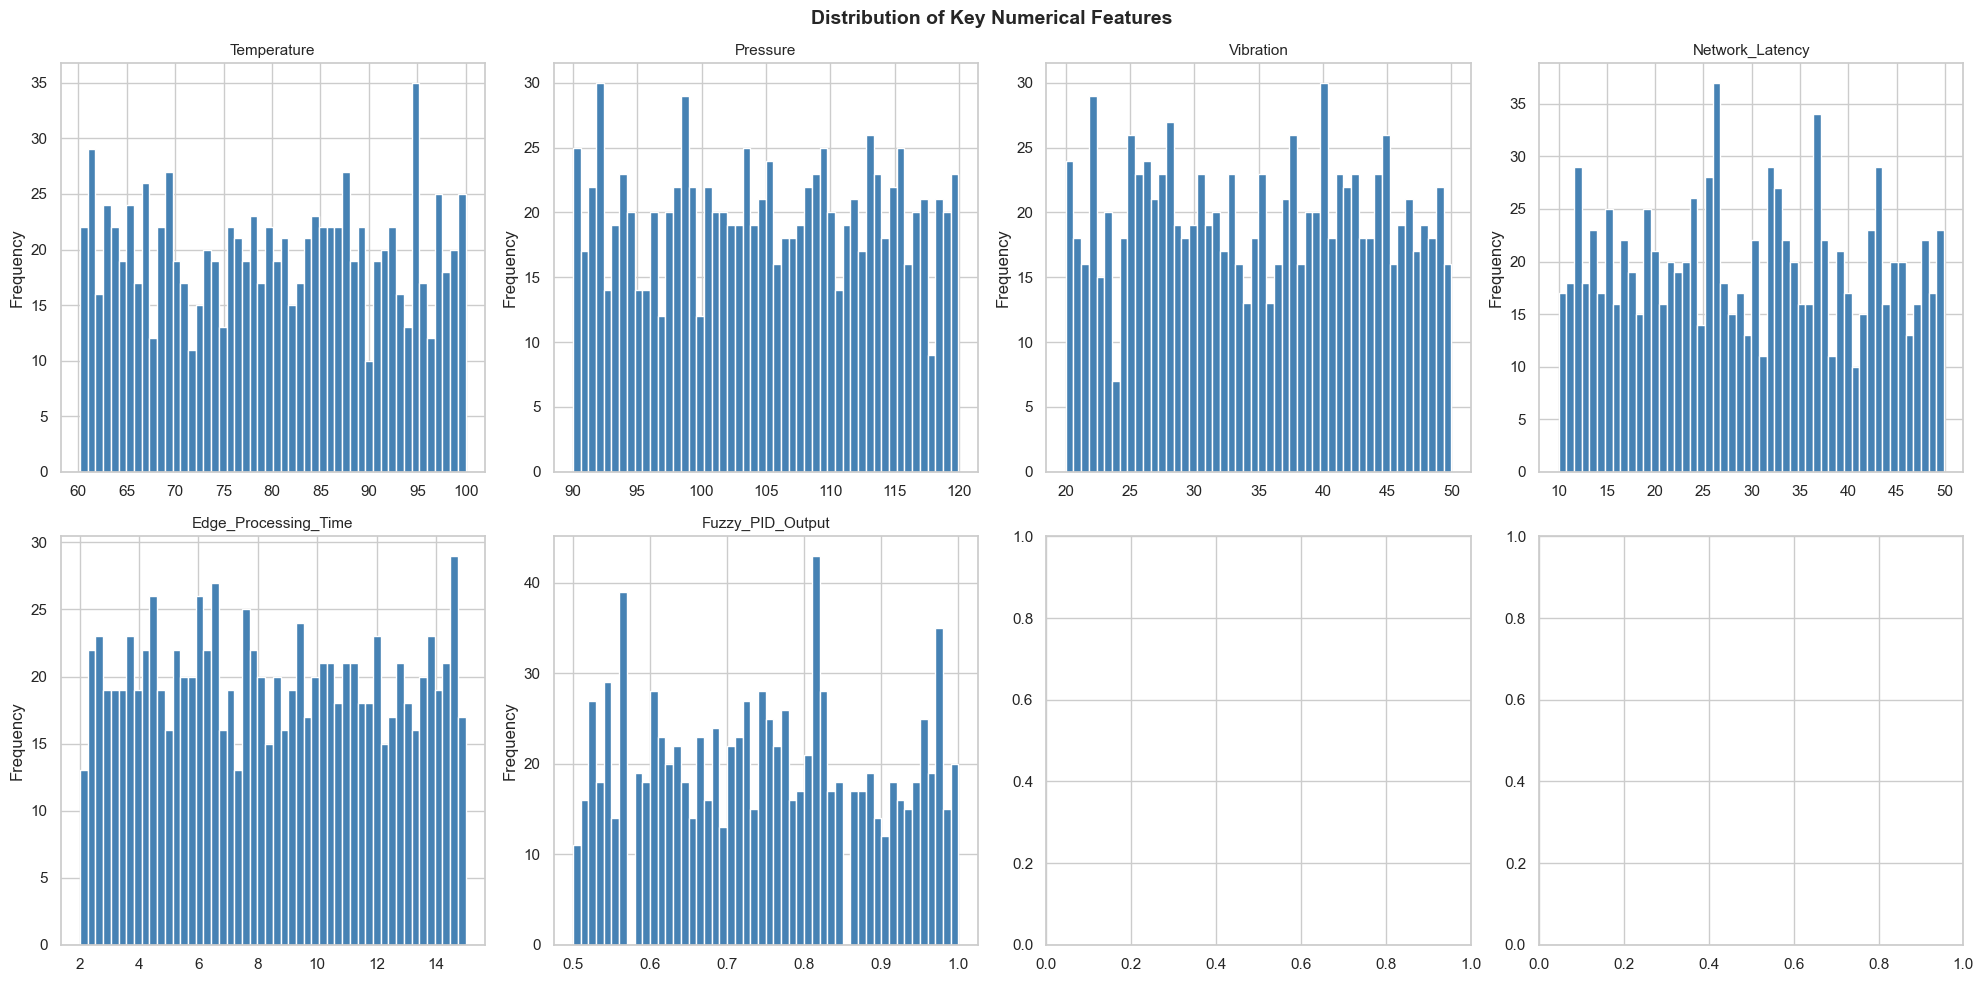

In [17]:
# Distribution of key continuous features

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, feat in enumerate(key_features):
    ax = axes[i // 4][i % 4]
    df[feat].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(feat, fontsize=11)
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Key Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

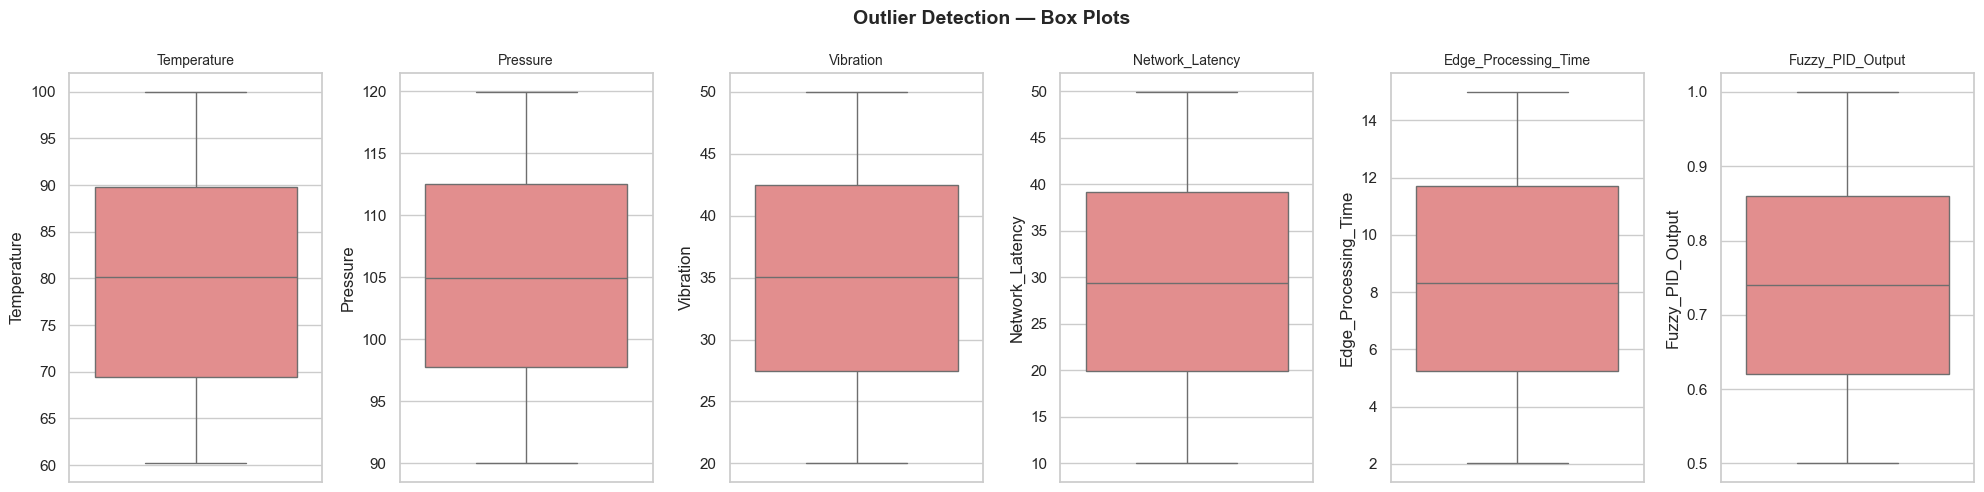

In [18]:
# Box plots for continuous features to visualize outliers
outlier_features = ['Temperature', 'Pressure', 'Vibration', 'Network_Latency', 'Edge_Processing_Time', 'Fuzzy_PID_Output']

fig, axes = plt.subplots(1, len(outlier_features), figsize=(20, 5))
for i, feat in enumerate(outlier_features):
    sns.boxplot(y=df[feat], ax=axes[i], color='lightcoral')
    axes[i].set_title(feat, fontsize=10)

plt.suptitle('Outlier Detection — Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

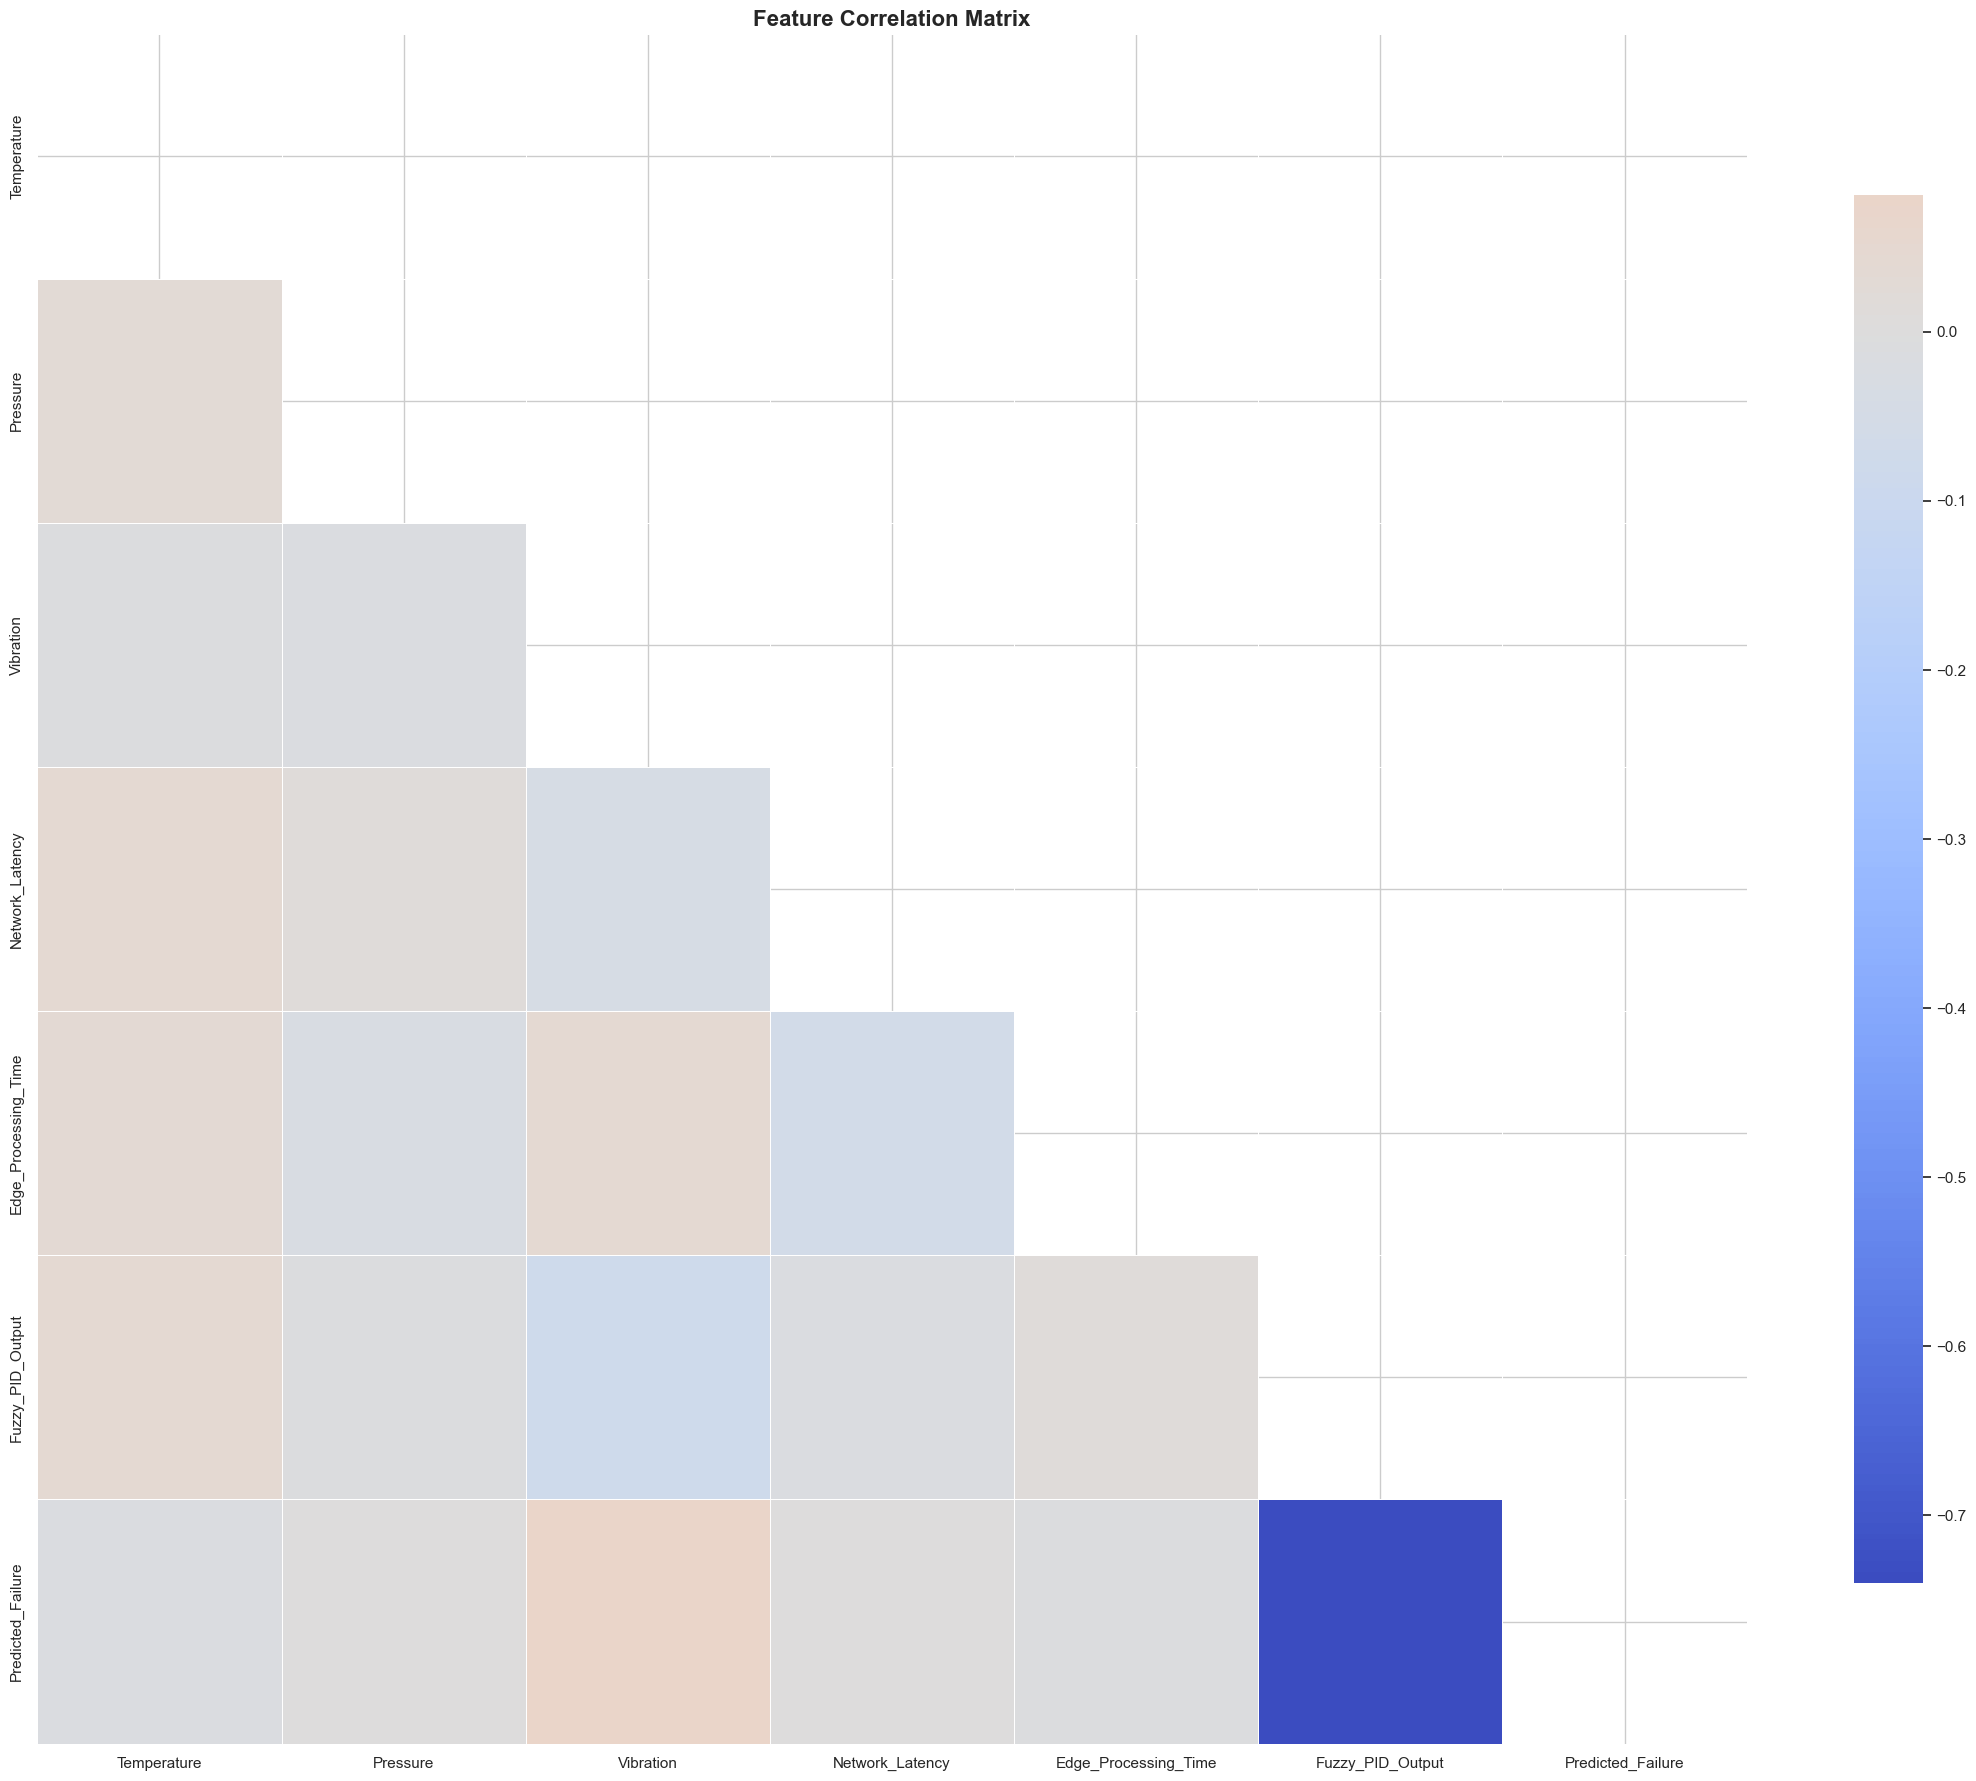

In [19]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(22, 18))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot=False,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Identify highly correlated feature pairs (|r| > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
print(f"Number of highly correlated pairs (|r| > 0.9): {len(high_corr_df)}")
high_corr_df

Number of highly correlated pairs (|r| > 0.9): 0


""


In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical features
le_sensor = LabelEncoder()
le_maintenance = LabelEncoder()

df['Sensor_ID_encoded'] = le_sensor.fit_transform(df['Sensor_ID'])
df['Maintenance_Status_encoded'] = le_maintenance.fit_transform(df['Maintenance_Status'])

# Print mappings
print("Sensor_ID Encoding:")
for name, code in zip(le_sensor.classes_, le_sensor.transform(le_sensor.classes_)):
    print(f"  {code}: {name}")

print("\nMaintenance_Status Encoding:")
for name, code in zip(le_maintenance.classes_, le_maintenance.transform(le_maintenance.classes_)):
    print(f"  {code}: {name}")

print(f"\nTarget variable 'Predicted_Failure' is already binary encoded (0/1)")

Sensor_ID Encoding:
  0: S1
  1: S2
  2: S3
  3: S4
  4: S5

Maintenance_Status Encoding:
  0: Failure
  1: Normal
  2: Warning

Target variable 'Predicted_Failure' is already binary encoded (0/1)


In [22]:
# Separate features and target
# Drop original categorical columns and timestamp, keep encoded versions
X = df.drop(['Timestamp', 'Sensor_ID', 'Maintenance_Status', 'Predicted_Failure'], axis=1)
y = df['Predicted_Failure']

# Scale numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Features shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {X_scaled.columns.tolist()}")
X_scaled.head()

Features shape: (1000, 8)
Target shape: (1000,)
Feature columns: ['Temperature', 'Pressure', 'Vibration', 'Network_Latency', 'Edge_Processing_Time', 'Fuzzy_PID_Output', 'Sensor_ID_encoded', 'Maintenance_Status_encoded']


,Temperature,Pressure,Vibration,Network_Latency,Edge_Processing_Time,Fuzzy_PID_Output,Sensor_ID_encoded,Maintenance_Status_encoded
0,1.476128,0.754983,-1.478209,0.144199,-1.154300,1.652843,0.695300,-0.194989
1,0.221788,-1.476884,0.431022,-1.356985,0.985660,-0.587256,1.393393,-2.052022
2,0.671310,-1.479751,1.678330,-1.114645,-1.298799,-1.357290,-0.002792,-2.052022
3,1.443251,-1.684661,-1.071427,0.269053,0.473021,0.112775,1.393393,-0.194989
4,0.707499,1.587043,1.022817,-0.681345,-1.294138,-1.497296,1.393393,-0.194989


In [23]:
# Winsorization: cap outliers at 1st and 99th percentiles
from scipy.stats import mstats

continuous_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in continuous_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers capped at 1st/99th percentiles (Winsorization applied).")

Outliers capped at 1st/99th percentiles (Winsorization applied).


In [24]:
# Save processed data for subsequent notebooks
processed_df = X_scaled.copy()
processed_df['Predicted_Failure'] = y.values

processed_df.to_csv('processed_iiot_edge.csv', index=False)
print("Processed data saved to 'processed_iiot_edge.csv'")
print(f"Final shape: {processed_df.shape}")

Processed data saved to 'processed_iiot_edge.csv'
Final shape: (1000, 9)


---
### Summary of EDA & Preprocessing
- **No missing values** found.
- **Moderate class imbalance** (1.2:1 ratio) between failure and non-failure cases.
- **Categorical features** (Sensor_ID, Maintenance_Status) encoded using LabelEncoder.
- **Outliers** handled via Winsorization at 1st/99th percentiles.
- **Features scaled** using StandardScaler.
- Data saved for use in Notebooks 2, 3, and 4.

In [31]:
# Separate features and target

# Separate features and target
# First, identify non-numeric columns to exclude
non_numeric_cols = ['Timestamp', 'Sensor_ID', 'Maintenance_Status']
numeric_cols = [col for col in df.columns if col not in non_numeric_cols and col != 'Predicted_Failure']

X = df[numeric_cols]
y = df['Predicted_Failure']

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Features shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")
X_scaled.head()


Features shape: (1000, 8)
Target shape: (1000,)


,Temperature,Pressure,Vibration,Network_Latency,Edge_Processing_Time,Fuzzy_PID_Output,Sensor_ID_encoded,Maintenance_Status_encoded
0,1.476824,0.755748,-1.479137,0.144158,-1.155281,1.654485,0.695300,-0.194989
1,0.221875,-1.477943,0.431352,-1.357901,0.986544,-0.587270,1.393393,-2.052022
2,0.671615,-1.480813,1.679482,-1.115420,-1.299905,-1.357873,-0.002792,-2.052022
3,1.443931,-1.685890,-1.072087,0.269085,0.473458,0.113279,1.393393,-0.194989
4,0.707821,1.588487,1.023537,-0.681867,-1.295240,-1.497982,1.393393,-0.194989


### 2.8 Save Processed Data

In [33]:
# Create processed dataframe with scaled features
processed_df = X_scaled.copy()

# Add the target variable (no separate 'label' column in this dataset)
processed_df['Predicted_Failure'] = y.values

# Save to CSV
processed_df.to_csv('processed_iiot_edge_computing.csv', index=False)
print("Processed data saved to 'processed_iiot_edge_computing.csv'")
print(f"Final shape: {processed_df.shape}")

Processed data saved to 'processed_iiot_edge_computing.csv'
Final shape: (1000, 9)


---
### Summary of EDA & Preprocessing
- **No missing values** found.
- **Significant class imbalance** across multiple attack types.
- **Outliers** handled via Winsorization at 1st/99th percentiles.
- **Features scaled** using StandardScaler.
- **Labels encoded** to integers.
- Data saved for use in Notebooks 2, 3, and 4.